<a href="https://colab.research.google.com/github/BobTheConstructor/Estudos/blob/main/Teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [212]:
explicacao = ([
    'sim ou não uma empresa',
    'o nome da empresa ou cliente',
    'cpf para pessoa fisica e cpnj para empresas',
    'data da compra',
    'porte do veiculo medio(carros), grande(caminhões)',
    'tipo de veiculo',
    'a medida do pneu',
    'se o pneu é uma restauração de um pneu usado',
    'a quantidade de pneus comprados',
    'o valor de cada pneu individual comprado',
    'o valor total da(s) venda(s) do(s) pneu(s)'
])

In [213]:
#bibliotecas Python para dados
import pandas as pd # utilizada para a criação do DataFrame
import numpy as np
import matplotlib.pyplot as plt # utilizada para a criação de graficos
import pyspark as sp
import seaborn as sns

Adcionando direto do computador o arquivo csv ao DataFrame: dds(dados)

In [214]:
from google.colab import files
dds = pd.read_csv(list(files.upload().keys())[0])

Saving dados_vendas.csv to dados_vendas (9).csv


Mostrando o tamanho do dataframe, privado

In [215]:
dds.shape

(800, 11)

Mostrando o metadados do DataFrame dds e explicando sobre cada coluna

In [216]:
meta = pd.DataFrame({
    'Coluna': dds.columns,
    'Tipo': [dds[col].dtype for col in dds.columns],
    'Explicacao': explicacao,
    'Exemplo de Valor': [dds[col].iloc[0] for col in dds.columns]
})
meta

,Coluna,Tipo,Explicacao,Exemplo de Valor
0,empresa,object,sim ou não uma empresa,Sim
1,Nome,object,o nome da empresa ou cliente,Costela
2,cpf_cnpj,object,cpf para pessoa fisica e cpnj para empresas,97.430.286/0001-87
3,data_compra,object,data da compra,22/06/2022
4,veiculo_porte,object,"porte do veiculo medio(carros), grande(caminhões)",medio
5,tipo_veiculo,object,tipo de veiculo,carro
6,medida_pneu,object,a medida do pneu,195/75.13
7,Remolde,object,se o pneu é uma restauração de um pneu usado,Sim
8,Qnt_vendas,int64,a quantidade de pneus comprados,4
9,Vr_unitario,float64,o valor de cada pneu individual comprado,171.45


Excluindo a coluna "tipo de veiculo" pois se torna redundante, ja que tipo_porte faz a mesma função porem de forma simplificada

In [217]:
dds = dds.drop(columns='tipo_veiculo')
dds.head()

,empresa,Nome,cpf_cnpj,data_compra,veiculo_porte,medida_pneu,Remolde,Qnt_vendas,Vr_unitario,Vr_Total
0,Sim,Costela,97.430.286/0001-87,22/06/2022,medio,195/75.13,Sim,4,171.45,685.80
1,Não,Cauê Pinto,730.265.841-26,18/08/2022,grande,205/55.15,Não,5,216.69,1083.45
2,Sim,Dias e Filhos,32.097.465/0001-07,05/07/2023,medio,195/65.16,Sim,1,162.62,162.62
3,Não,Lorenzo da Luz,196.043.728-31,23/04/2025,medio,165/65.14,Sim,1,161.67,161.67
4,Não,Dra. Cecília Freitas,085.329.164-06,12/06/2024,grande,215/65.15,Não,3,226.08,678.24


Mostrando as 10 primeiras linhas do dataframe dds

In [218]:
dds.head(10)

,empresa,Nome,cpf_cnpj,data_compra,veiculo_porte,medida_pneu,Remolde,Qnt_vendas,Vr_unitario,Vr_Total
0,Sim,Costela,97.430.286/0001-87,22/06/2022,medio,195/75.13,Sim,4,171.45,685.80
1,Não,Cauê Pinto,730.265.841-26,18/08/2022,grande,205/55.15,Não,5,216.69,1083.45
2,Sim,Dias e Filhos,32.097.465/0001-07,05/07/2023,medio,195/65.16,Sim,1,162.62,162.62
3,Não,Lorenzo da Luz,196.043.728-31,23/04/2025,medio,165/65.14,Sim,1,161.67,161.67
4,Não,Dra. Cecília Freitas,085.329.164-06,12/06/2024,grande,215/65.15,Não,3,226.08,678.24
5,Não,Vitor Fernandes,106.429.573-80,29/12/2023,medio,185/65.16,Não,6,226.93,1361.58
6,Não,Dr. Rael da Rosa,268.051.397-59,24/09/2023,grande,215/70.15,Sim,6,182.81,1096.86
7,Não,Maria Eduarda Câmara,025.647.139-80,14/02/2025,grande,205/60.16,Não,1,236.16,236.16
8,Não,Theodoro Barros,514.789.263-09,23/04/2025,grande,205/55.17,Sim,6,164.54,987.24
9,Não,Luigi Novaes,830.124.679-04,21/01/2024,medio,195/65.15,Não,6,236.01,1416.06


Atualizando o todos os nomes das colunas para lowerCase (minusculo)

In [219]:
dds.columns = [col.lower() for col in dds.columns]

Mostrando as 10 maiores vendas de todos os tempos da loja, tendo em conta o limite de 6 pneus p/compra

In [222]:
dds.loc[dds.groupby('cpf_cnpj')['vr_total'].idxmax()].sort_values(by="vr_total", ascending=False).head(10)

,empresa,nome,cpf_cnpj,data_compra,veiculo_porte,medida_pneu,remolde,qnt_vendas,vr_unitario,vr_total
346,Não,Sr. Vinícius Rocha,126.045.983-70,26/01/2025,medio,175/65.15,Não,6,249.76,1498.56
518,Não,Srta. Eduarda da Costa,248.609.751-11,08/07/2023,grande,225/65.15,Não,6,247.97,1487.82
734,Não,Luiz Miguel Rios,348.719.052-41,25/05/2024,medio,175/75.14,Não,6,247.82,1486.92
314,Sim,Lopes,71.095.846/0001-09,18/10/2024,grande,215/60.16,Não,6,246.16,1476.96
303,Sim,Sampaio,85.960.143/0001-06,31/01/2024,grande,205/45.15,Não,6,245.75,1474.50
786,Sim,Aparecida,73.916.485/0001-31,10/06/2023,medio,165/75.13,Não,6,244.12,1464.72
151,Não,Léo Farias,134.062.579-25,09/03/2025,grande,215/70.17,Não,6,243.89,1463.34
418,Não,Sr. Antony Ramos,074.123.895-05,27/09/2024,grande,225/60.17,Não,6,243.17,1459.02
795,Sim,Almeida,59.608.342/0001-31,21/08/2023,grande,215/55.15,Não,6,241.51,1449.06
402,Não,Sr. Fernando das Neves,284.306.951-33,28/07/2022,grande,225/65.15,Não,6,239.61,1437.66


Manipulação simples do DataFrame com spark

Inicializando uma sessão do spark sql

In [223]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ExemploSQL").getOrCreate()

In [224]:
spdados = sp.createDataFrame(dds)

AttributeError: module 'pyspark' has no attribute 'createDataFrame'

In [70]:
spdados.show()
spdados.createOrReplaceTempView("dados")

+-------+--------------------+------------------+-----------+-------------+------------+-----------+-------+----------+-----------+--------+
|empresa|                Nome|          cpf_cnpj|data_compra|veiculo_porte|tipo_veiculo|medida_pneu|Remolde|Qnt_vendas|Vr_unitario|Vr_Total|
+-------+--------------------+------------------+-----------+-------------+------------+-----------+-------+----------+-----------+--------+
|    Sim|             Costela|97.430.286/0001-87| 22/06/2022|        medio|       carro|  195/75.13|    Sim|         4|     171.45|   685.8|
|    Não|          Cauê Pinto|    730.265.841-26| 18/08/2022|       grande|    caminhão|  205/55.15|    Não|         5|     216.69| 1083.45|
|    Sim|       Dias e Filhos|32.097.465/0001-07| 05/07/2023|        medio|       carro|  195/65.16|    Sim|         1|     162.62|  162.62|
|    Não|      Lorenzo da Luz|    196.043.728-31| 23/04/2025|        medio|       carro|  165/65.14|    Sim|         1|     161.67|  161.67|
|    Não|Dra.

In [71]:
query = """ SELECT Nome, medida_pneu, COUNT(*) as total
            FROM dados
            GROUP BY 1, 2
            ORDER BY 3 desc"""

exdados = spark.sql(query)

print(exdados.show())

+-------------+-----------+-----+
|         Nome|medida_pneu|total|
+-------------+-----------+-----+
|   Nascimento|  225/60.16|    3|
|    Aparecida|  225/60.17|    3|
|   Nascimento|  165/65.14|    3|
|    Aparecida|  165/75.15|    3|
|Dias e Filhos|  215/70.17|    3|
|  Porto Ltda.|  195/75.13|    3|
|      Sampaio|  185/75.13|    3|
|      Almeida|  185/65.15|    3|
|      Costela|  185/75.16|    3|
|  Porto Ltda.|  185/75.15|    2|
|      Sampaio|  225/70.16|    2|
|      Sampaio|  225/60.15|    2|
|  Porto Ltda.|  215/45.15|    2|
|   Cavalcante|  175/75.14|    2|
|  Porto Ltda.|  165/65.14|    2|
|Dias e Filhos|  205/65.17|    2|
|  Porto Ltda.|  195/75.14|    2|
|   Nascimento|  225/65.17|    2|
|Dias e Filhos|  215/60.17|    2|
|        Lopes|  225/70.17|    2|
+-------------+-----------+-----+
only showing top 20 rows

None


In [78]:
pd.DataFrame(exdados.collect(), columns=exdados.columns)

,Nome,medida_pneu,total
0,Nascimento,225/60.16,3
1,Aparecida,225/60.17,3
2,Nascimento,165/65.14,3
3,Aparecida,165/75.15,3
4,Dias e Filhos,215/70.17,3
...,...,...,...
716,Theodoro Vieira,195/75.15,1
717,Aylla Fogaça,205/45.15,1
718,Aparecida,185/75.16,1
719,Costela,215/70.17,1


In [124]:
dds

,empresa,Nome,cpf_cnpj,data_compra,veiculo_porte,tipo_veiculo,medida_pneu,Remolde,Qnt_vendas,Vr_unitario,Vr_Total
0,Sim,Costela,97.430.286/0001-87,22/06/2022,medio,carro,195/75.13,Sim,4,171.45,685.80
1,Não,Cauê Pinto,730.265.841-26,18/08/2022,grande,caminhão,205/55.15,Não,5,216.69,1083.45
2,Sim,Dias e Filhos,32.097.465/0001-07,05/07/2023,medio,carro,195/65.16,Sim,1,162.62,162.62
3,Não,Lorenzo da Luz,196.043.728-31,23/04/2025,medio,carro,165/65.14,Sim,1,161.67,161.67
4,Não,Dra. Cecília Freitas,085.329.164-06,12/06/2024,grande,caminhão,215/65.15,Não,3,226.08,678.24
...,...,...,...,...,...,...,...,...,...,...,...
795,Sim,Almeida,59.608.342/0001-31,21/08/2023,grande,caminhão,215/55.15,Não,6,241.51,1449.06
796,Sim,Nascimento,04.163.295/0001-78,11/05/2023,medio,carro,195/65.13,Sim,5,160.10,800.50
797,Sim,Sampaio,85.960.143/0001-06,27/11/2022,medio,carro,195/65.16,Sim,2,165.43,330.86
798,Sim,Cavalcante,65.098.174/0001-84,14/06/2022,grande,caminhão,215/65.17,Sim,3,165.55,496.65


Criação do grafico de pizza, demonstrando o valor total gasto por cada empresa

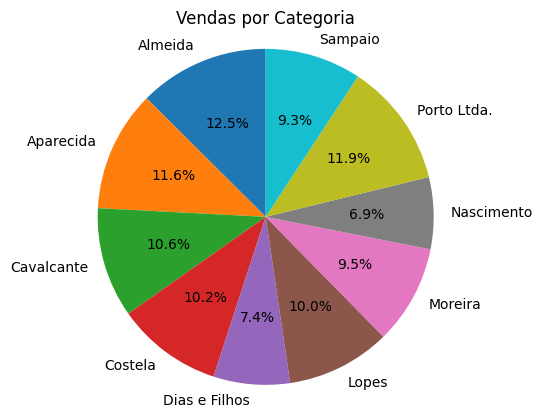

In [134]:
filtro = dds[dds['empresa'] == 'Sim']
teste = filtro.groupby('Nome')['Vr_Total'].sum()

plt.pie(teste, labels=teste.index, autopct='%1.1f%%',startangle=90)
plt.title('Vendas por Categoria')
plt.axis('equal')
plt.show()

In [168]:
filtro = dds['data_compra']
teste = pd.to_datetime(filtro, format='%d/%m/%Y')
teste = teste.dt.month
filtro

,data_compra
0,22/06/2022
1,18/08/2022
2,05/07/2023
3,23/04/2025
4,12/06/2024
...,...
795,21/08/2023
796,11/05/2023
797,27/11/2022
798,14/06/2022


In [169]:
teste

,data_compra
0,6
1,8
2,7
3,4
4,6
...,...
795,8
796,5
797,11
798,6


<ipython-input-210-4034984124>:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


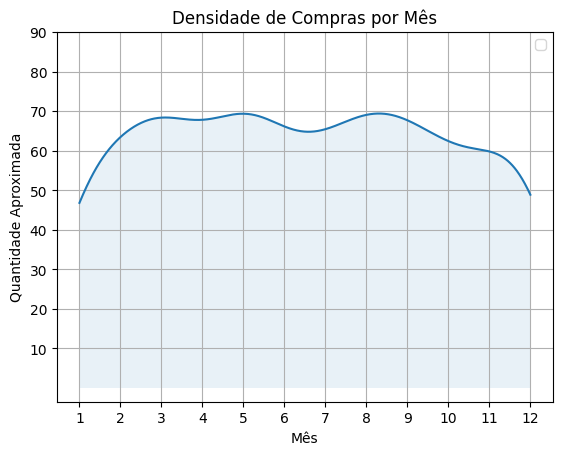

In [210]:
from scipy.stats import gaussian_kde

# Preparar dados
meses = teste
kde = gaussian_kde(meses)
x = np.linspace(1, 12, 1000)
y = kde(x) * len(meses)

plt.plot(x, y, label="")
plt.fill_between(x, y, alpha=0.1)
plt.title('Densidade de Compras por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade Aproximada')
plt.xticks(range(1, 13))
plt.yticks(range(10, 100, 10))
plt.grid(True)
plt.legend()
plt.show()

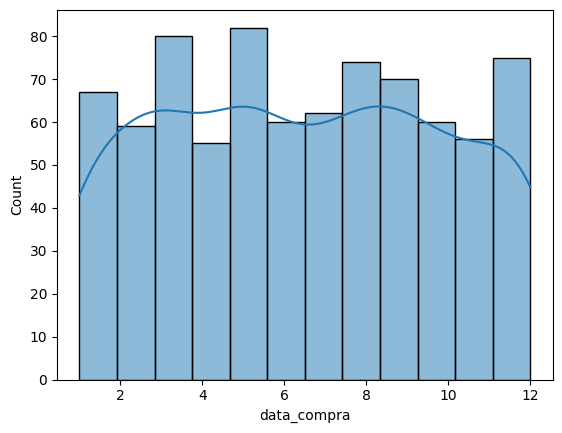

In [174]:
sns.histplot(teste, bins=12, kde=True)
plt.show()